In [1]:
#Load
import pandas as pd

df = pd.read_excel(r'/Users/mahfuzulahsanniloy/Downloads/Absenteeism_at_work.xlsx')
df

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,no_of_offspring,Social drinker,Social smoker,no_of_Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239554,...,0,1,2,1,0,1,90,172,30,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,11,14,7,3,1,289,36,13,33,264604,...,0,1,2,1,0,1,90,172,30,8
736,1,11,7,3,1,235,11,14,37,264604,...,0,3,1,0,0,1,88,172,29,4
737,4,0,0,3,1,118,14,13,40,271219,...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,271219,...,0,1,2,1,0,2,100,170,35,0


In [2]:
#Question 1 — Data Overview & Cleaning
df.isna().mean()*100

ID                                 0.0
Reason for absence                 0.0
Month of absence                   0.0
Day of the week                    0.0
Seasons                            0.0
Transportation expense             0.0
Distance from Residence to Work    0.0
Service time                       0.0
Age                                0.0
Work load Average/day              0.0
Hit target                         0.0
Disciplinary failure               0.0
Education                          0.0
no_of_offspring                    0.0
Social drinker                     0.0
Social smoker                      0.0
no_of_Pet                          0.0
Weight                             0.0
Height                             0.0
Body mass index                    0.0
Absenteeism time in hours          0.0
dtype: float64

In [3]:
df.duplicated().sum()

np.int64(34)

In [4]:
df.dtypes

ID                                 int64
Reason for absence                 int64
Month of absence                   int64
Day of the week                    int64
Seasons                            int64
Transportation expense             int64
Distance from Residence to Work    int64
Service time                       int64
Age                                int64
Work load Average/day              int64
Hit target                         int64
Disciplinary failure               int64
Education                          int64
no_of_offspring                    int64
Social drinker                     int64
Social smoker                      int64
no_of_Pet                          int64
Weight                             int64
Height                             int64
Body mass index                    int64
Absenteeism time in hours          int64
dtype: object

In [5]:
df.drop('ID', axis=1, inplace=True)

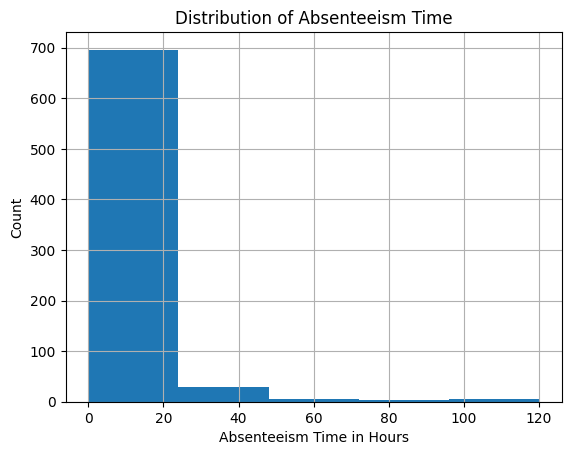

In [6]:
#Question 2 — Distribution of Absenteeism hours
import matplotlib.pyplot as plt

df['Absenteeism time in hours'].hist(bins=5)
plt.title('Distribution of Absenteeism Time')
plt.xlabel('Absenteeism Time in Hours')
plt.ylabel('Count')
plt.show()

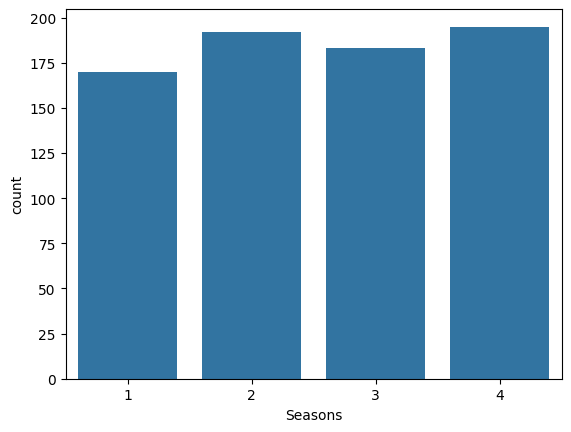

In [7]:
#Question 3 — Which season has most absenteeism
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Seasons', data=df)
plt.show()

In [8]:
df.groupby(['Seasons'])[['Absenteeism time in hours']].sum().sort_values(['Absenteeism time in hours'], ascending=False)

,Absenteeism time in hours
Seasons,
3,1492
1,1241
4,1239
2,1152


In [ ]:
#Question 4 — Does social drinking/smoking impact absenteeism
sns.countplot(x='Social drinker', hue='Disciplinary failure', data=df)
plt.show()

In [ ]:
sns.countplot(x='Social smoker', hue='Disciplinary failure', data=df)
plt.show()

In [ ]:
#Question 5 — Correlation between all features
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.groupby(['Disciplinary failure']).mean(numeric_only=True)

In [ ]:
#Question 6 — Linear Regression (predict Absenteeism hours)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Transportation expense', 'Distance from Residence to Work', 'Age', 'Work load Average/day ', 'Body mass index', 'Service time']]
y = df['Absenteeism time in hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

In [ ]:
#Question 7 — Logistic Regression (predict Disciplinary failure 0/1)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['Transportation expense', 'Age', 'Work load Average/day ', 'Social drinker', 'Social smoker', 'Body mass index']]
y = df['Disciplinary failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

In [ ]:
#Question 8 — Decision Tree (predict Disciplinary failure)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = df[['Transportation expense', 'Age', 'Work load Average/day ', 'Social drinker', 'Social smoker', 'Body mass index']]
y = df['Disciplinary failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)